In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
tickers = [
    "MMM",
    "AOS",
    "ABT",
    "ABBV",
    "ACN",
    "ADBE",
    "AMD",
    "AES",
    "AFL",
    "A",
    "APD",
    "ABNB",
    "AKAM",
    "ALB",
    "ARE",
    "ALGN",
    "ALLE",
    "LNT",
    "ALL",
    "GOOGL",
    "GOOG",
    "MO",
    "AMZN",
    "AMCR",
    "AEE",
    "AEP",
    "AXP",
    "AIG",
    "AMT",
    "AWK",
    "AMP",
    "AME",
    "AMGN",
    "APH",
    "ADI",
    "AON",
    "APA",
    "APO",
    "AAPL",
    "AMAT",
    "APP",
    "APTV",
    "ACGL",
    "ADM",
    "ARES",
    "ANET",
    "AJG",
    "AIZ",
    "T",
    "ATO",
    "ADSK",
    "ADP",
    "AZO",
    "AVB",
    "AVY",
    "AXON",
    "BKR",
    "BALL",
    "BAC",
    "BAX",
    "BDX",
    "BRK",
    "BBY",
    "TECH",
    "BIIB",
    "BLK",
    "BX",
    "XYZ",
    "BK",
    "BA",
    "BKNG",
    "BSX",
    "BMY",
    "AVGO",
    "BR",
    "BRO",
    "BF",
    "BLDR",
    "BG",
    "BXP",
    "CHRW",
    "CDNS",
    "CPT",
    "CPB",
    "COF",
    "CAH",
    "CCL",
    "CARR",
    "CVNA",
    "CASY",
    "CAT",
    "CBOE",
    "CBRE",
    "CDW",
    "COR",
    "CNC",
    "CNP",
    "CF",
    "CRL",
    "SCHW",
    "CHTR",
    "CVX",
    "CMG",
    "CB",
    "CHD",
    "CIEN",
    "CI",
    "CINF",
    "CTAS",
    "CSCO",
    "C",
    "CFG",
    "CLX",
    "CME",
    "CMS",
    "KO",
    "CTSH",
    "COHR",
    "COIN",
    "CL",
    "CMCSA",
    "FIX",
    "CAG",
    "COP",
    "ED",
    "STZ",
    "CEG",
    "COO",
    "CPRT",
    "GLW",
    "CPAY",
    "CTVA",
    "CSGP",
    "COST",
    "CTRA",
    "CRH",
    "CRWD",
    "CCI",
    "CSX",
    "CMI",
    "CVS",
    "DHR",
    "DRI",
    "DDOG",
    "DVA",
    "DECK",
    "DE",
    "DELL",
    "DAL",
    "DVN",
    "DXCM",
    "FANG",
    "DLR",
    "DG",
    "DLTR",
    "D",
    "DPZ",
    "DASH",
    "DOV",
    "DOW",
    "DHI",
    "DTE",
    "DUK",
    "DD",
    "ETN",
    "EBAY",
    "SATS",
    "ECL",
    "EIX",
    "EW",
    "EA",
    "ELV",
    "EME",
    "EMR",
    "ETR",
    "EOG",
    "EPAM",
    "EQT",
    "EFX",
    "EQIX",
    "EQR",
    "ERIE",
    "ESS",
    "EL",
    "EG",
    "EVRG",
    "ES",
    "EXC",
    "EXE",
    "EXPE",
    "EXPD",
    "EXR",
    "XOM",
    "FFIV",
    "FDS",
    "FICO",
    "FAST",
    "FRT",
    "FDX",
    "FIS",
    "FITB",
    "FSLR",
    "FE",
    "FISV",
    "F",
    "FTNT",
    "FTV",
    "FOXA",
    "FOX",
    "BEN",
    "FCX",
    "GRMN",
    "IT",
    "GE",
    "GEHC",
    "GEV",
    "GEN",
    "GNRC",
    "GD",
    "GIS",
    "GM",
    "GPC",
    "GILD",
    "GPN",
    "GL",
    "GDDY",
    "GS",
    "HAL",
    "HIG",
    "HAS",
    "HCA",
    "DOC",
    "HSIC",
    "HSY",
    "HPE",
    "HLT",
    "HD",
    "HON",
    "HRL",
    "HST",
    "HWM",
    "HPQ",
    "HUBB",
    "HUM",
    "HBAN",
    "HII",
    "IBM",
    "IEX",
    "IDXX",
    "ITW",
    "INCY",
    "IR",
    "PODD",
    "INTC",
    "IBKR",
    "ICE",
    "IFF",
    "IP",
    "INTU",
    "ISRG",
    "IVZ",
    "INVH",
    "IQV",
    "IRM",
    "JBHT",
    "JBL",
    "JKHY",
    "J",
    "JNJ",
    "JCI",
    "JPM",
    "KVUE",
    "KDP",
    "KEY",
    "KEYS",
    "KMB",
    "KIM",
    "KMI",
    "KKR",
    "KLAC",
    "KHC",
    "KR",
    "LHX",
    "LH",
    "LRCX",
    "LVS",
    "LDOS",
    "LEN",
    "LII",
    "LLY",
    "LIN",
    "LYV",
    "LMT",
    "L",
    "LOW",
    "LULU",
    "LITE",
    "LYB",
    "MTB",
    "MPC",
    "MAR",
    "MRSH",
    "MLM",
    "MAS",
    "MA",
    "MKC",
    "MCD",
    "MCK",
    "MDT",
    "MRK",
    "META",
    "MET",
    "MTD",
    "MGM",
    "MCHP",
    "MU",
    "MSFT",
    "MAA",
    "MRNA",
    "TAP",
    "MDLZ",
    "MPWR",
    "MNST",
    "MCO",
    "MS",
    "MOS",
    "MSI",
    "MSCI",
    "NDAQ",
    "NTAP",
    "NFLX",
    "NEM",
    "NWSA",
    "NWS",
    "NEE",
    "NKE",
    "NI",
    "NDSN",
    "NSC",
    "NTRS",
    "NOC",
    "NCLH",
    "NRG",
    "NUE",
    "NVDA",
    "NVR",
    "NXPI",
    "ORLY",
    "OXY",
    "ODFL",
    "OMC",
    "ON",
    "OKE",
    "ORCL",
    "OTIS",
    "PCAR",
    "PKG",
    "PLTR",
    "PANW",
    "PSKY",
    "PH",
    "PAYX",
    "PYPL",
    "PNR",
    "PEP",
    "PFE",
    "PCG",
    "PM",
    "PSX",
    "PNW",
    "PNC",
    "POOL",
    "PPG",
    "PPL",
    "PFG",
    "PG",
    "PGR",
    "PLD",
    "PRU",
    "PEG",
    "PTC",
    "PSA",
    "PHM",
    "PWR",
    "QCOM",
    "DGX",
    "Q",
    "RL",
    "RJF",
    "RTX",
    "O",
    "REG",
    "REGN",
    "RF",
    "RSG",
    "RMD",
    "RVTY",
    "HOOD",
    "ROK",
    "ROL",
    "ROP",
    "ROST",
    "RCL",
    "SPGI",
    "CRM",
    "SNDK",
    "SBAC",
    "SLB",
    "STX",
    "SRE",
    "NOW",
    "SHW",
    "SPG",
    "SWKS",
    "SJM",
    "SW",
    "SNA",
    "SOLV",
    "SO",
    "LUV",
    "SWK",
    "SBUX",
    "STT",
    "STLD",
    "STE",
    "SYK",
    "SMCI",
    "SYF",
    "SNPS",
    "SYY",
    "TMUS",
    "TROW",
    "TTWO",
    "TPR",
    "TRGP",
    "TGT",
    "TEL",
    "TDY",
    "TER",
    "TSLA",
    "TXN",
    "TPL",
    "TXT",
    "TMO",
    "TJX",
    "TKO",
    "TTD",
    "TSCO",
    "TT",
    "TDG",
    "TRV",
    "TRMB",
    "TFC",
    "TYL",
    "TSN",
    "USB",
    "UBER",
    "UDR",
    "ULTA",
    "UNP",
    "UAL",
    "UPS",
    "URI",
    "UNH",
    "UHS",
    "VLO",
    "VTR",
    "VLTO",
    "VRSN",
    "VRSK",
    "VZ",
    "VRTX",
    "VRT",
    "VTRS",
    "VICI",
    "V",
    "VST",
    "VMC",
    "WRB",
    "GWW",
    "WAB",
    "WMT",
    "DIS",
    "WBD",
    "WM",
    "WAT",
    "WEC",
    "WFC",
    "WELL",
    "WST",
    "WDC",
    "WY",
    "WSM",
    "WMB",
    "WTW",
    "WDAY",
    "WYNN",
    "XEL",
    "XYL",
    "YUM",
    "ZBRA",
    "ZBH",
    "ZTS",
]

In [78]:
data = yf.download(tickers, start="2015-01-01", end="2023-12-31")

[************          25%                       ]  126 of 503 completed$BRK: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31)
[**********************57%**                     ]  287 of 503 completed$BF: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31)
[**********************65%******                 ]  329 of 503 completed$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
[**********************77%************           ]  386 of 503 completed$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
[**********************94%********************   ]  471 of 503 completed$Q: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
[***

In [86]:
close_df = data["Close"].dropna(axis=1)
volume_df = data["Volume"].dropna(axis=1)
position_cnt = 30
returns_df = close_df.pct_change().fillna(0)

In [31]:
# market_data = yf.download(['SPY', 'XLK'], start="2020-01-01", end="2023-12-31")

[*********************100%***********************]  2 of 2 completed


## Test - Realized Vol

In [89]:
sr = {}

for mt_wind in [60, 80, 100, 120, 140]:
    for vol_wind in [10, 20, 30, 40, 50, 60, 70, 80]:
        base_signal = returns_df.shift(5).rolling(mt_wind).mean().shift(1)

        realized_vol = returns_df.rolling(vol_wind).std()
        vol_thresh = realized_vol.rolling(60).quantile(0.8)

        # realized_vol = returns_df.rolling(50).std()
        # vol_thresh = realized_vol.quantile(0.85, axis=1)
        signal_df = base_signal.where(realized_vol.lt(vol_thresh, axis=0))

        # NOTE: liquidity filter
        dollar_vol_df = (close_df * volume_df).dropna(axis=1)
        avg_dollar_vol_df = dollar_vol_df.rolling(60).mean()

        rank_df = avg_dollar_vol_df.rank(axis=1, ascending=False)
        rank_mask = rank_df <= 250

        filtered_returns = returns_df.where(rank_mask)
        filtered_signal_df = signal_df.where(rank_mask)

        signal_rank = filtered_signal_df.rank(axis=1, ascending=False, na_option="bottom")

        long = signal_rank <= position_cnt
        short_cutoff = signal_rank.count(axis=1) - (position_cnt - 1)
        short = signal_rank.ge(short_cutoff.values[:, None])

        positions = long.astype(int) - short.astype(int)
        positions = positions.div(positions.abs().sum(axis=1), axis=0)

        # NOTE: rebalance weekly
        rebalance_mask = positions.index.to_series().dt.weekday == 0
        positions_weekly = positions.where(rebalance_mask)
        positions_weekly = positions_weekly.ffill()

        # rebalance_mask = np.arange(len(positions)) % 5 == 0
        # positions_weekly = positions.copy()
        # positions_weekly[~rebalance_mask] = np.nan
        # positions_weekly = positions_weekly.ffill()

        pnl = positions_weekly.shift(1) * filtered_returns
        port_ret = pnl.sum(axis=1)
        sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)

        mt_wind_key = f"{mt_wind}"
        if mt_wind_key not in sr:
            sr[mt_wind_key] = {}

        vol_wind_key = f"{vol_wind}"
        sr[mt_wind_key][vol_wind_key] = sharpe

        # cum_pnl = (1 + port_ret).cumprod()
        # ax = cum_pnl.plot()
        # plt.text(
        #     0.02,
        #     0.02,
        #     f"Sharpe: {sharpe:.2f}",
        #     transform=ax.transAxes
        # )
        # plt.show()

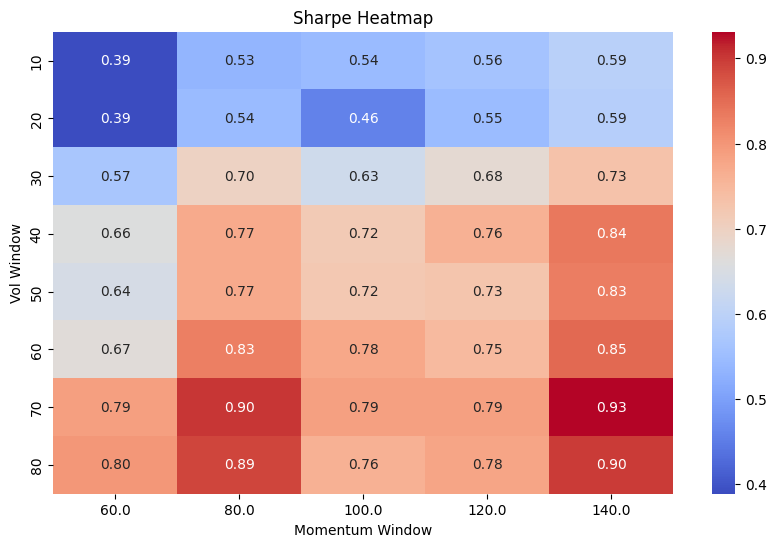

In [90]:
hm_df = pd.DataFrame(sr).astype(float)
hm_df.index = hm_df.index.astype(int)  # vol window
hm_df.columns = hm_df.columns.astype(float)  # quantiles

plt.figure(figsize=(10, 6))
sns.heatmap(hm_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.xlabel("Momentum Window")
plt.ylabel("Vol Window")
plt.title("Sharpe Heatmap")
plt.show()

## Test 2 - Realized Vol

In [82]:
sr = {}
mt_wind = 120
for qt in [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
    for vol_wind in [10, 20, 30, 40, 50, 60, 70, 80]:
        base_signal = returns_df.shift(5).rolling(mt_wind).mean().shift(1)

        realized_vol = returns_df.rolling(40).std()
        vol_thresh = realized_vol.rolling(vol_wind).quantile(qt)

        # realized_vol = returns_df.rolling(50).std()
        # vol_thresh = realized_vol.quantile(0.85, axis=1)
        signal_df = base_signal.where(realized_vol.lt(vol_thresh, axis=0))

        dollar_vol_df = (close_df * volume_df).dropna(axis=1)
        avg_dollar_vol_df = dollar_vol_df.rolling(60).mean()

        rank_df = avg_dollar_vol_df.rank(axis=1, ascending=False)
        rank_mask = rank_df <= 250

        filtered_returns = returns_df.where(rank_mask)
        filtered_signal_df = signal_df.where(rank_mask)

        signal_rank = filtered_signal_df.rank(axis=1, ascending=False)

        long = signal_rank <= position_cnt
        short_cutoff = signal_rank.count(axis=1) - (position_cnt - 1)
        short = signal_rank.ge(short_cutoff.values[:, None])

        positions = long.astype(int) - short.astype(int)
        positions = positions.div(positions.abs().sum(axis=1), axis=0)

        # NOTE: rebalance weekly
        rebalance_mask = positions.index.to_series().dt.weekday == 0
        positions_weekly = positions.where(rebalance_mask)
        positions_weekly = positions_weekly.ffill()

        # rebalance_mask = np.arange(len(positions)) % 5 == 0
        # positions_weekly = positions.copy()
        # positions_weekly[~rebalance_mask] = np.nan
        # positions_weekly = positions_weekly.ffill()

        pnl = positions_weekly.shift(1) * filtered_returns
        port_ret = pnl.sum(axis=1)
        sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)

        qt_key = f"{qt}"
        if qt_key not in sr:
            sr[qt_key] = {}

        vol_wind_key = f"{vol_wind}"
        sr[qt_key][vol_wind_key] = sharpe

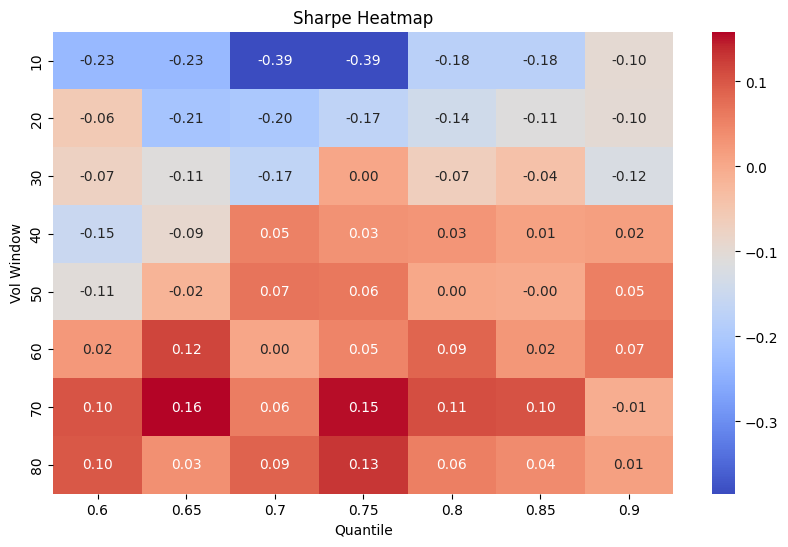

In [83]:
hm_df = pd.DataFrame(sr).astype(float)
hm_df.index = hm_df.index.astype(int)  # vol window
hm_df.columns = hm_df.columns.astype(float)  # quantiles

plt.figure(figsize=(10, 6))
sns.heatmap(hm_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.xlabel("Quantile")
plt.ylabel("Vol Window")
plt.title("Sharpe Heatmap")
plt.show()

## Test 3 - momentum window

In [84]:
sr = {}

for mt_wind in [60, 80, 100, 120, 140]:
    for vol_wind in [10, 20, 30, 40, 50, 60, 70, 80]:
        base_signal = returns_df.shift(5).rolling(mt_wind).mean().shift(1)

        realized_vol = returns_df.rolling(40).std()
        vol_thresh = realized_vol.rolling(vol_wind).quantile(0.8)

        # realized_vol = returns_df.rolling(50).std()
        # vol_thresh = realized_vol.quantile(0.85, axis=1)
        signal_df = base_signal.where(realized_vol.lt(vol_thresh, axis=0))

        dollar_vol_df = (close_df * volume_df).dropna(axis=1)
        avg_dollar_vol_df = dollar_vol_df.rolling(60).mean()

        rank_df = avg_dollar_vol_df.rank(axis=1, ascending=False)
        rank_mask = rank_df <= 250

        filtered_returns = returns_df.where(rank_mask)
        filtered_signal_df = signal_df.where(rank_mask)

        signal_rank = filtered_signal_df.rank(axis=1, ascending=False)

        long = signal_rank <= position_cnt
        short_cutoff = signal_rank.count(axis=1) - (position_cnt - 1)
        short = signal_rank.ge(short_cutoff.values[:, None])

        positions = long.astype(int) - short.astype(int)
        positions = positions.div(positions.abs().sum(axis=1), axis=0)

        # NOTE: rebalance weekly
        rebalance_mask = positions.index.to_series().dt.weekday == 0
        positions_weekly = positions.where(rebalance_mask)
        positions_weekly = positions_weekly.ffill()

        pnl = positions_weekly.shift(1) * filtered_returns
        port_ret = pnl.sum(axis=1)
        sharpe = port_ret.mean() / port_ret.std() * np.sqrt(252)

        mt_wind_key = f"{mt_wind}"
        if mt_wind_key not in sr:
            sr[mt_wind_key] = {}

        vol_wind_key = f"{vol_wind}"
        sr[mt_wind_key][vol_wind_key] = sharpe

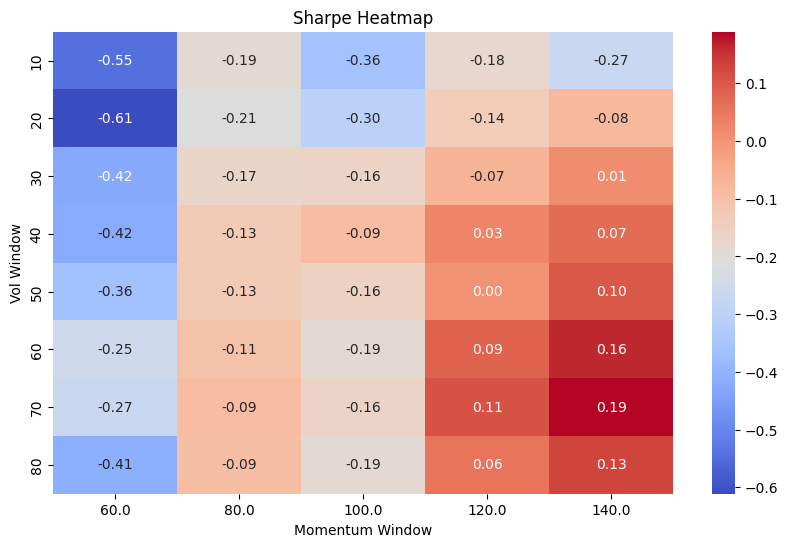

In [85]:
hm_df = pd.DataFrame(sr).astype(float)
hm_df.index = hm_df.index.astype(int)  # vol window
hm_df.columns = hm_df.columns.astype(float)  # quantiles

plt.figure(figsize=(10, 6))
sns.heatmap(hm_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.xlabel("Momentum Window")
plt.ylabel("Vol Window")
plt.title("Sharpe Heatmap")
plt.show()